# EDA notebook

**This notebook is for exploratory data analysis (EDA) on the dataset. We will be using Python and various libraries such as pandas, matplotlib, and seaborn to analyze the data and visualize the results.**

*See at the end for description of analysis steps and findings.*

## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import pyarrow.parquet as pq
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120

## Load a sample

we'll not use full dataset, big size, low RAM :(

In [2]:
pf = pq.ParquetFile('/kaggle/input/datasets/vineet0san/cms-e2e-jets/data00.parquet')

batch = next(pf.iter_batches(batch_size=5000))
df = batch.to_pandas()

print(f"Sample size: {len(df)}")
print(f"Columns: {df.columns.tolist()}")
print(f"\nBasic info:")
print(df[['m', 'pt', 'ieta', 'iphi']].describe())

Sample size: 5000
Columns: ['X_jet', 'm', 'iphi', 'pt', 'ieta']

Basic info:
                 m           pt         ieta         iphi
count  5000.000000  5000.000000  5000.000000  5000.000000
mean    293.178021   693.412545    27.413800    35.690000
std     119.163147   172.561761     8.270348    20.947641
min      85.291336   400.359009    12.000000     0.000000
25%     189.640263   540.933899    21.000000    17.000000
50%     294.745499   687.117676    27.000000    36.000000
75%     394.942520   845.022751    34.000000    54.000000
max     499.795746   999.986023    43.000000    71.000000


## Plot Distribution

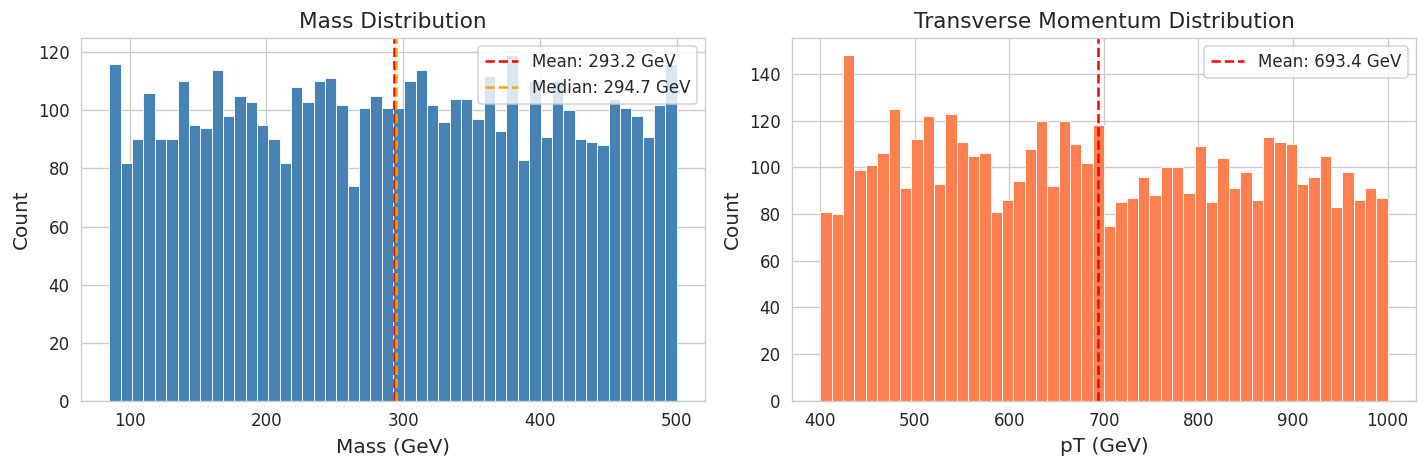

Mass range: 85.3 - 499.8 GeV
Mass std: 119.2 GeV
Is mass uniform? std/range = 0.287


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram
axes[0].hist(df['m'], bins=50, color='steelblue', edgecolor='white', linewidth=0.5)
axes[0].set_xlabel('Mass (GeV)', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_title('Mass Distribution', fontsize=13)
axes[0].axvline(df['m'].mean(), color='red', linestyle='--', label=f"Mean: {df['m'].mean():.1f} GeV")
axes[0].axvline(df['m'].median(), color='orange', linestyle='--', label=f"Median: {df['m'].median():.1f} GeV")
axes[0].legend()

# pT distribution
axes[1].hist(df['pt'], bins=50, color='coral', edgecolor='white', linewidth=0.5)
axes[1].set_xlabel('pT (GeV)', fontsize=12)
axes[1].set_ylabel('Count', fontsize=12)
axes[1].set_title('Transverse Momentum Distribution', fontsize=13)
axes[1].axvline(df['pt'].mean(), color='red', linestyle='--', label=f"Mean: {df['pt'].mean():.1f} GeV")
axes[1].legend()

plt.tight_layout()
plt.savefig('mass_pt_distribution.png', dpi=150)
plt.show()
print(f"Mass range: {df['m'].min():.1f} - {df['m'].max():.1f} GeV")
print(f"Mass std: {df['m'].std():.1f} GeV")
print(f"Is mass uniform? std/range = {df['m'].std()/(df['m'].max()-df['m'].min()):.3f}")

## Correlation (`m` vs `pT`)

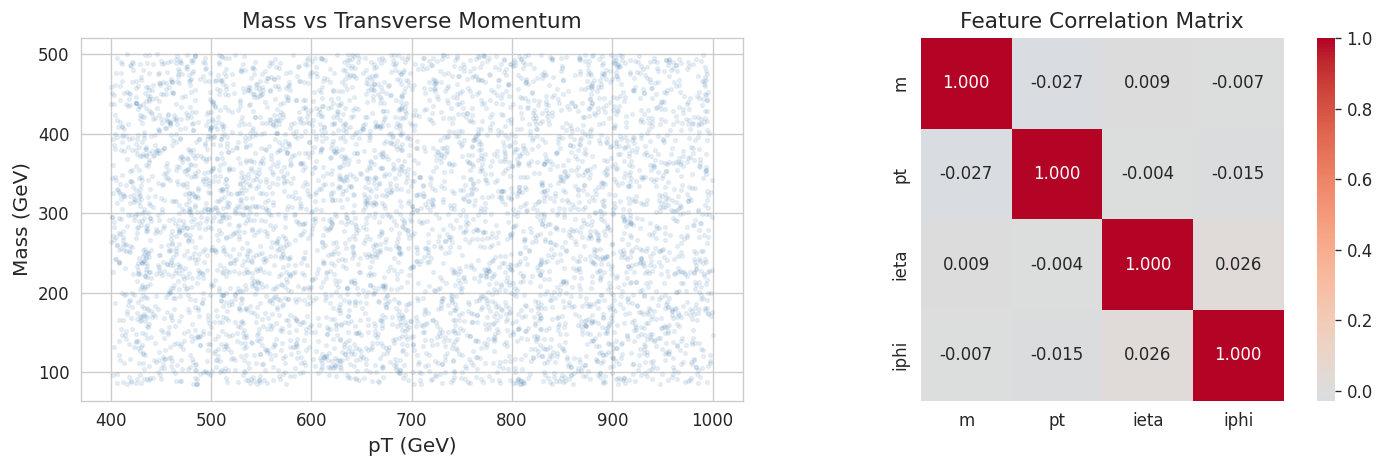

Correlation with mass:
ieta    0.008919
iphi   -0.006557
pt     -0.027175
Name: m, dtype: float64


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Mass vs pT
axes[0].scatter(df['pt'], df['m'], alpha=0.1, s=5, color='steelblue')
axes[0].set_xlabel('pT (GeV)', fontsize=12)
axes[0].set_ylabel('Mass (GeV)', fontsize=12)
axes[0].set_title('Mass vs Transverse Momentum', fontsize=13)

# Correlation heatmap
corr = df[['m', 'pt', 'ieta', 'iphi']].corr()
sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm',
            center=0, ax=axes[1], square=True)
axes[1].set_title('Feature Correlation Matrix', fontsize=13)

plt.tight_layout()
plt.savefig('correlations.png', dpi=150)
plt.show()
print("Correlation with mass:")
print(corr['m'].drop('m').sort_values(ascending=False))

## Channel Sparsity Analysis

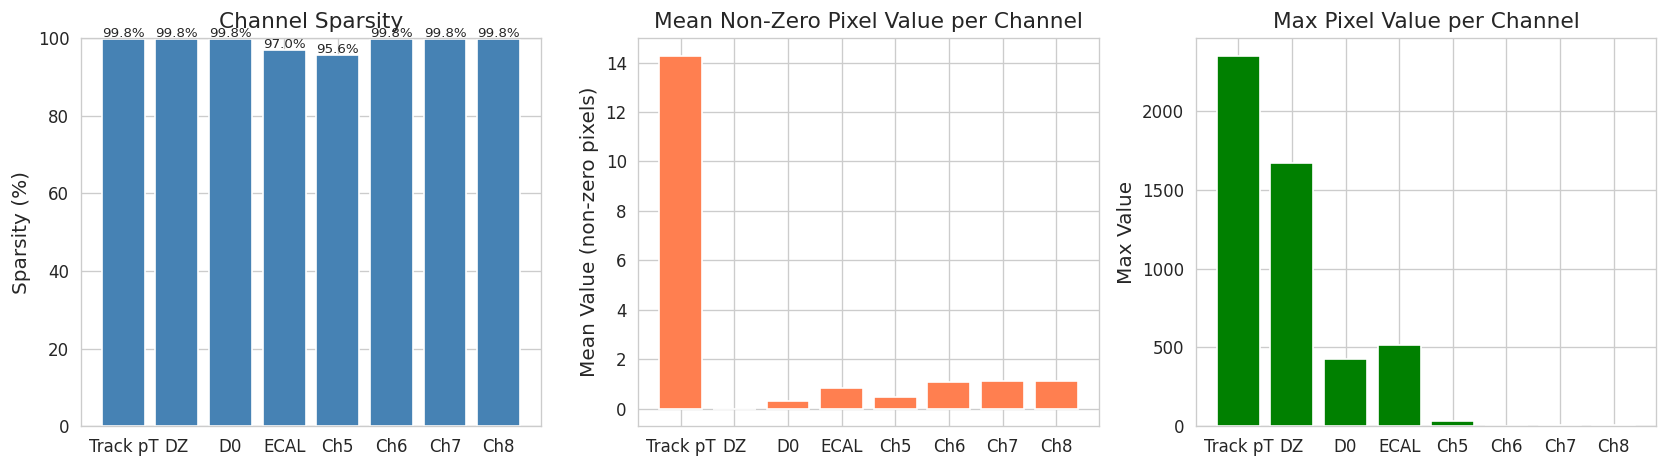

Channel Statistics:
  Track pT: sparsity=99.8% | mean_nonzero=14.278 | max=2344.820
  DZ: sparsity=99.8% | mean_nonzero=-0.006 | max=1666.605
  D0: sparsity=99.8% | mean_nonzero=0.309 | max=427.878
  ECAL: sparsity=97.0% | mean_nonzero=0.823 | max=515.357
  Ch5: sparsity=95.6% | mean_nonzero=0.479 | max=35.377
  Ch6: sparsity=99.8% | mean_nonzero=1.081 | max=4.000
  Ch7: sparsity=99.8% | mean_nonzero=1.109 | max=6.000
  Ch8: sparsity=99.8% | mean_nonzero=1.129 | max=9.000


In [5]:
channel_names = ['Track pT', 'DZ', 'D0', 'ECAL', 'Ch5', 'Ch6', 'Ch7', 'Ch8']

sparsity = []
mean_nonzero = []
max_vals = []

for ch in range(8):
    pixels = []
    for _, row in df.iloc[:500].iterrows():  # sample 500 events
        xjet = row['X_jet']
        img = np.stack([xjet[ch][r] for r in range(125)]).astype(np.float32)
        pixels.append(img.flatten())
    pixels = np.concatenate(pixels)
    
    sparsity.append((pixels == 0).mean() * 100)
    mean_nonzero.append(pixels[pixels != 0].mean() if (pixels != 0).any() else 0)
    max_vals.append(pixels.max())

# Plot
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].bar(channel_names, sparsity, color='steelblue', edgecolor='white')
axes[0].set_ylabel('Sparsity (%)', fontsize=12)
axes[0].set_title('Channel Sparsity', fontsize=13)
axes[0].set_ylim(0, 100)
for i, v in enumerate(sparsity):
    axes[0].text(i, v+0.5, f'{v:.1f}%', ha='center', fontsize=8)

axes[1].bar(channel_names, mean_nonzero, color='coral', edgecolor='white')
axes[1].set_ylabel('Mean Value (non-zero pixels)', fontsize=12)
axes[1].set_title('Mean Non-Zero Pixel Value per Channel', fontsize=13)

axes[2].bar(channel_names, max_vals, color='green', edgecolor='white')
axes[2].set_ylabel('Max Value', fontsize=12)
axes[2].set_title('Max Pixel Value per Channel', fontsize=13)

plt.tight_layout()
plt.savefig('channel_sparsity.png', dpi=150)
plt.show()

print("Channel Statistics:")
for i, name in enumerate(channel_names):
    print(f"  {name}: sparsity={sparsity[i]:.1f}% | mean_nonzero={mean_nonzero[i]:.3f} | max={max_vals[i]:.3f}")

## Outlier Detection

In [6]:
extreme_events = []

for idx, row in df.iterrows():
    xjet = row['X_jet']
    for ch in range(4):
        img = np.stack([xjet[ch][r] for r in range(125)]).astype(np.float32)
        max_val = img.max()
        min_val = img.min()
        if max_val > 500 or min_val < -100:
            extreme_events.append({
                'idx': idx,
                'channel': channel_names[ch],
                'max': max_val,
                'min': min_val,
                'mass': row['m']
            })

extreme_df = pd.DataFrame(extreme_events)
print(f"Extreme events found: {len(extreme_df)}")
print(f"\nBy channel:")
print(extreme_df.groupby('channel')[['max', 'min']].describe())
print(f"\nSample extreme events:")
print(extreme_df.sort_values('max', ascending=False).head(10))

Extreme events found: 1229

By channel:
            max                                                     \
          count         mean           std         min         25%   
channel                                                              
D0        746.0    95.894478    110.388512    1.377735   37.831182   
DZ        387.0    72.922401    171.273499    0.740036   13.425069   
ECAL        4.0   528.625427     21.271540  505.840332  512.977875   
Track pT   92.0  3841.641357  10785.004883  513.499756  679.401443   

                                                   min              \
                 50%          75%           max  count        mean   
channel                                                              
D0         63.637327   115.655184   1233.779053  746.0 -163.657242   
DZ         34.325714    71.554382   1799.683472  387.0 -205.786194   
ECAL      529.764709   545.412262    549.131958    4.0    0.000000   
Track pT  886.760254  1920.996796  74054.406250  

## Average Jet event visualisation

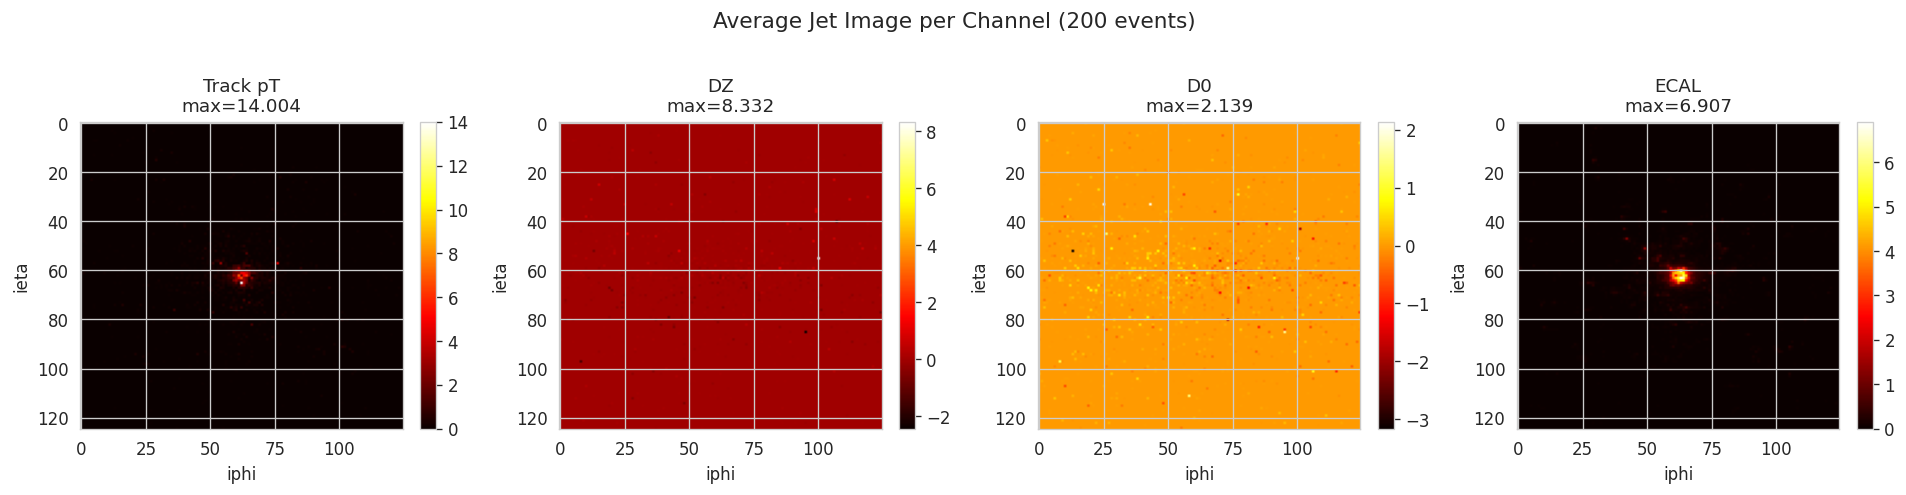

In [7]:
n_events = 200
avg_images = np.zeros((4, 125, 125))

for _, row in df.iloc[:n_events].iterrows():
    xjet = row['X_jet']
    for ch in range(4):
        img = np.stack([xjet[ch][r] for r in range(125)]).astype(np.float32)
        avg_images[ch] += img

avg_images /= n_events

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ch in range(4):
    im = axes[ch].imshow(avg_images[ch], cmap='hot', aspect='auto')
    axes[ch].set_title(f'{channel_names[ch]}\nmax={avg_images[ch].max():.3f}', fontsize=11)
    axes[ch].set_xlabel('iphi', fontsize=10)
    axes[ch].set_ylabel('ieta', fontsize=10)
    plt.colorbar(im, ax=axes[ch], fraction=0.046)

plt.suptitle('Average Jet Image per Channel (200 events)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('average_jet_images.png', dpi=150)
plt.show()

## Single event visualisation

Visualizing highest mass event: 499.8 GeV, pT=446.0 GeV


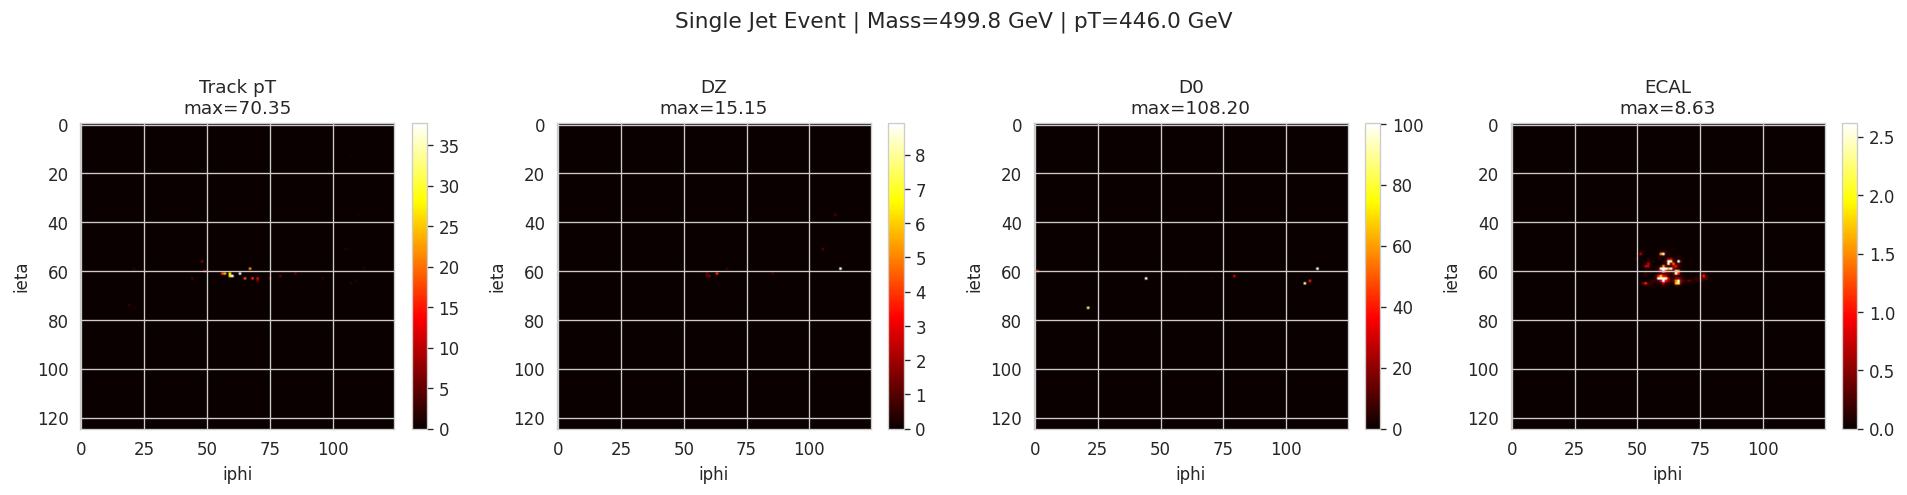

In [8]:
high_mass_idx = df['m'].idxmax()
row = df.loc[high_mass_idx]
print(f"Visualizing highest mass event: {row['m']:.1f} GeV, pT={row['pt']:.1f} GeV")

xjet = row['X_jet']
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ch in range(4):
    img = np.stack([xjet[ch][r] for r in range(125)]).astype(np.float32)
    # Clip for visualization
    vmax = np.percentile(img[img > 0], 95) if (img > 0).any() else 1
    im = axes[ch].imshow(img, cmap='hot', aspect='auto', vmin=0, vmax=vmax)
    axes[ch].set_title(f'{channel_names[ch]}\nmax={img.max():.2f}', fontsize=11)
    axes[ch].set_xlabel('iphi', fontsize=10)
    axes[ch].set_ylabel('ieta', fontsize=10)
    plt.colorbar(im, ax=axes[ch], fraction=0.046)

plt.suptitle(f'Single Jet Event | Mass={row["m"]:.1f} GeV | pT={row["pt"]:.1f} GeV', 
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('single_jet_event.png', dpi=150)
plt.show()

In [9]:
print("=== NORMALIZATION ANALYSIS ===\n")
print("Channel value ranges (from 500 sample events):")
print(f"{'Channel':<12} {'Min':>10} {'Max':>10} {'Scale Ratio':>12}")
print("-" * 46)

ranges = [
    ('Track pT', 0, 74054),
    ('DZ',       -4174, 1800),
    ('D0',       -1190, 1234),
    ('ECAL',     0,     549),
]

for name, mn, mx in ranges:
    ratio = mx / 549  # relative to ECAL
    print(f"{name:<12} {mn:>10.1f} {mx:>10.1f} {ratio:>11.1f}x")

print("\nTrack pT is 135x larger than ECAL")
print("This causes gradient explosion during training")
print("Per-channel normalization is critical for stable training")
print("\n→ Recommendation: Apply per-channel standardization before training")
print("→ clip extreme values at 99th percentile, then normalize to [0,1]")

=== NORMALIZATION ANALYSIS ===

Channel value ranges (from 500 sample events):
Channel             Min        Max  Scale Ratio
----------------------------------------------
Track pT            0.0    74054.0       134.9x
DZ              -4174.0     1800.0         3.3x
D0              -1190.0     1234.0         2.2x
ECAL                0.0      549.0         1.0x

Track pT is 135x larger than ECAL
This causes gradient explosion during training
Per-channel normalization is critical for stable training

→ Recommendation: Apply per-channel standardization before training
→ clip extreme values at 99th percentile, then normalize to [0,1]


## EDA Summary

### Dataset Characteristics
- Mass distribution: **uniform** across 85-500 GeV (std/range = 0.287)
- Scalar features (pt, ieta, iphi) have **near-zero correlation** with mass
- Mass is entirely encoded in the **spatial image structure**

### Channel Analysis
| Channel | Sparsity | Max Value | Issue |
|---------|----------|-----------|-------|
| Track pT | 99.8% | 74,054 | Extreme outliers |
| DZ | 99.8% | ±4,174 | Large negative values |
| D0 | 99.8% | ±1,234 | Large negative values |
| ECAL | 97.0% | 549 | Most stable |

### Critical Finding
- **24.6% of events contain extreme pixel values**
- Track pT outliers up to 74,054 GeV (135x ECAL scale)
- This directly caused training loss spikes in chunks 6, 23, 35, 47
- **Per-channel normalization and outlier clipping required**

### Limitations
- This EDA was performed on a **sample of 5,000 events** from file 0 only
- Full dataset contains ~600,000 events across 4 files
- Observed statistics (sparsity, outlier rates, value ranges) may not 
  be fully representative of the complete dataset
- Notably, the 24.6% outlier rate and extreme Track pT values (max=74,054) 
  could be specific to this file or sample
- A full dataset EDA would require distributed processing beyond 
  the scope of this analysis

### Conclusions
- Mass uniformity and near-zero scalar correlations are likely robust 
  findings - these are by dataset design
- Channel scale mismatch (135x) is a structural property of the 
  physics, unlikely to change across files
- Exact outlier rates and extreme values should be treated as 
  **indicative, not definitive**
- Normalization recommendation stands regardless, 
  even if outlier rate varies, the scale mismatch alone justifies it

### Recommendations for Next Training Run
1. Clip each channel at 99th percentile
2. Normalize each channel to [0,1]
3. This should eliminate training spikes and improve convergence